# Here in this assignment I tried for the following models for finding a better accuracy one,
1. LSTM
2. Bidirectional LSTM

# Step 1: Import Required Libraries

In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, SimpleRNN
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

# Step 2: Load the Dataset

Do the following under Step 2,

1. Download the csv file
2. Upload the csv file in Colab
3. Load the dataset

In [77]:
# Load the data
df = pd.read_csv('/content/judge-1377884607_tweet_product_company.csv', encoding='latin1')

# Display the first 5 rows
df.head()

,tweet_text,emotion_in_tweet_is_directed_at,is_there_an_emotion_directed_at_a_brand_or_product
0,.@wesley83 I have a 3G iPhone. After 3 hrs twe...,iPhone,Negative emotion
1,@jessedee Know about @fludapp ? Awesome iPad/i...,iPad or iPhone App,Positive emotion
2,@swonderlin Can not wait for #iPad 2 also. The...,iPad,Positive emotion
3,@sxsw I hope this year's festival isn't as cra...,iPad or iPhone App,Negative emotion
4,@sxtxstate great stuff on Fri #SXSW: Marissa M...,Google,Positive emotion


# Step 3: Select Required Columns

In [78]:
# We only keep the text and the sentiment column
df = df[['tweet_text', 'is_there_an_emotion_directed_at_a_brand_or_product']]

# Remove any rows where the tweet text is empty/NaN
df = df.dropna(subset=['tweet_text'])

# Check the shape of the data
print(f"Dataset size: {df.shape}")

Dataset size: (9092, 2)


# Step 4: EDA (Exploration)

is_there_an_emotion_directed_at_a_brand_or_product
No emotion toward brand or product    5388
Positive emotion                      2978
Negative emotion                       570
I can't tell                           156
Name: count, dtype: int64


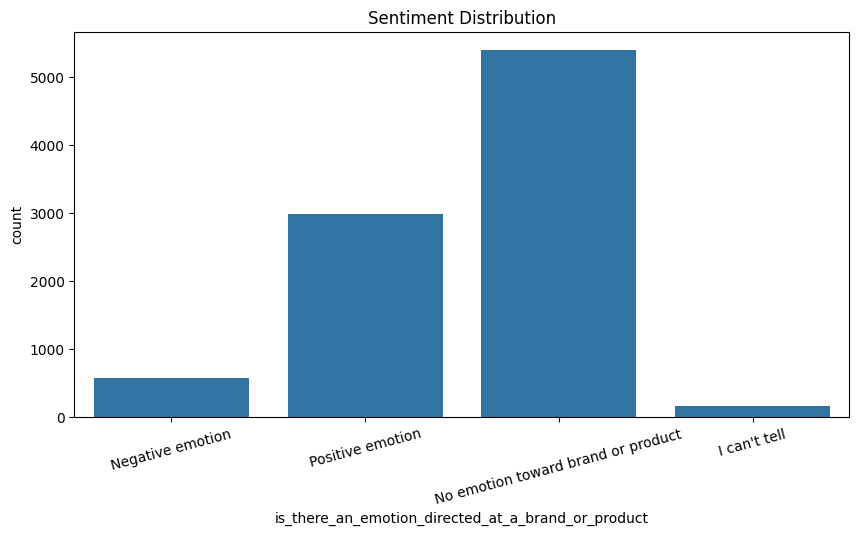

In [79]:
# Count the occurrences of each sentiment
print(df['is_there_an_emotion_directed_at_a_brand_or_product'].value_counts())

# Plot the distribution
plt.figure(figsize=(10, 5))
sns.countplot(x='is_there_an_emotion_directed_at_a_brand_or_product', data=df)
plt.title('Sentiment Distribution')
plt.xticks(rotation=15)
plt.show()

# Step 5: Data Cleaning

In [80]:
def clean_tweet(text):
    text = str(text).lower() # Convert to lowercase
    text = re.sub(r'https?://\S+|www\.\S+', '', text) # Remove links
    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text) # Remove punctuation
    text = re.sub(r'\n', '', text) # Remove new lines
    text = re.sub(r'\w*\d\w*', '', text) # Remove words containing numbers
    return text

# Apply cleaning to the tweet_text column
df['cleaned_text'] = df['tweet_text'].apply(clean_tweet)

# Show a sample of cleaned text
df[['tweet_text', 'cleaned_text']].head()

,tweet_text,cleaned_text
0,.@wesley83 I have a 3G iPhone. After 3 hrs twe...,i have a iphone after hrs tweeting at risea...
1,@jessedee Know about @fludapp ? Awesome iPad/i...,jessedee know about fludapp awesome ipadiphon...
2,@swonderlin Can not wait for #iPad 2 also. The...,swonderlin can not wait for ipad also they sh...
3,@sxsw I hope this year's festival isn't as cra...,sxsw i hope this years festival isnt as crashy...
4,@sxtxstate great stuff on Fri #SXSW: Marissa M...,sxtxstate great stuff on fri sxsw marissa maye...


# Step 6: Lable Encoding

In [81]:
# Initialize the encoder
label_encoder = LabelEncoder()

# Fit and transform the sentiment column
df['label'] = label_encoder.fit_transform(df['is_there_an_emotion_directed_at_a_brand_or_product'])

# Show the mapping (e.g., 0 = Negative, 1 = Positive, etc.)
mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print("Label Mapping:", mapping)

Label Mapping: {"I can't tell": np.int64(0), 'Negative emotion': np.int64(1), 'No emotion toward brand or product': np.int64(2), 'Positive emotion': np.int64(3)}


# Step 7: Train-Test Split

In [82]:
# Split the data
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    df['cleaned_text'],
    df['label'],
    test_size=0.2,
    random_state=42
)

print(f"Training samples: {len(X_train_raw)}")
print(f"Testing samples: {len(X_test_raw)}")

Training samples: 7273
Testing samples: 1819


# Step 8: Tokenization & Padding

In [83]:
max_words = 5000  # Number of unique words to keep
max_len = 100     # Length of each tweet sequence

# Initialize Tokenizer
tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(X_train_raw)

# Convert text to sequences of numbers
X_train = pad_sequences(tokenizer.texts_to_sequences(X_train_raw), maxlen=max_len)
X_test = pad_sequences(tokenizer.texts_to_sequences(X_test_raw), maxlen=max_len)

# Convert labels to categorical (One-Hot Encoding)
y_train = tf.keras.utils.to_categorical(y_train_raw, num_classes=4)
y_test = tf.keras.utils.to_categorical(y_test_raw, num_classes=4)

print("Tokenization and Padding complete.")

Tokenization and Padding complete.


# Step 9: Build LSTM Model

In [84]:
# Build the LSTM Model
model = Sequential([
    Embedding(max_words, 128, input_length=max_len), # Embedding layer for word vectors
    LSTM(64, dropout=0.2),                          # LSTM layer to remember word patterns
    Dense(32, activation='relu'),                   # Intermediate dense layer
    Dense(4, activation='softmax')                  # Output layer for 4 sentiment classes
])

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_7 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_8 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

# Step 10: Train the Model

In [85]:
# Train the model
epochs = 5
batch_size = 32

history = model.fit(
    X_train, y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=0.1
)

Epoch 1/5
205/205 ━━━━━━━━━━━━━━━━━━━━ 19s 79ms/step - accuracy: 0.5931 - loss: 0.9262 - val_accuracy: 0.6209 - val_loss: 0.8386
Epoch 2/5
205/205 ━━━━━━━━━━━━━━━━━━━━ 16s 80ms/step - accuracy: 0.6810 - loss: 0.7691 - val_accuracy: 0.6827 - val_loss: 0.7835
Epoch 3/5
205/205 ━━━━━━━━━━━━━━━━━━━━ 16s 79ms/step - accuracy: 0.7725 - loss: 0.6072 - val_accuracy: 0.6484 - val_loss: 0.8453
Epoch 4/5
205/205 ━━━━━━━━━━━━━━━━━━━━ 16s 76ms/step - accuracy: 0.8174 - loss: 0.4904 - val_accuracy: 0.6731 - val_loss: 0.8194
Epoch 5/5
205/205 ━━━━━━━━━━━━━━━━━━━━ 21s 81ms/step - accuracy: 0.8448 - loss: 0.4211 - val_accuracy: 0.6593 - val_loss: 0.9438


# Step 11: Evaluate Models

57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.6416 - loss: 1.0059
Test Accuracy: 64.16%


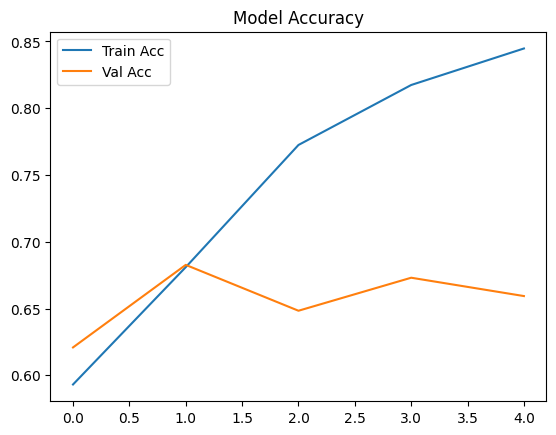

In [86]:
# Evaluate on test data
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

# Plot training & validation accuracy
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title('Model Accuracy')
plt.show()

# Step 12: Confusion Matrix + Report

57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step
Classification Report:
                                    precision    recall  f1-score   support

                      I can't tell       0.00      0.00      0.00        27
                  Negative emotion       0.51      0.27      0.35       121
No emotion toward brand or product       0.73      0.70      0.72      1065
                  Positive emotion       0.53      0.64      0.58       606

                          accuracy                           0.64      1819
                         macro avg       0.44      0.40      0.41      1819
                      weighted avg       0.64      0.64      0.64      1819



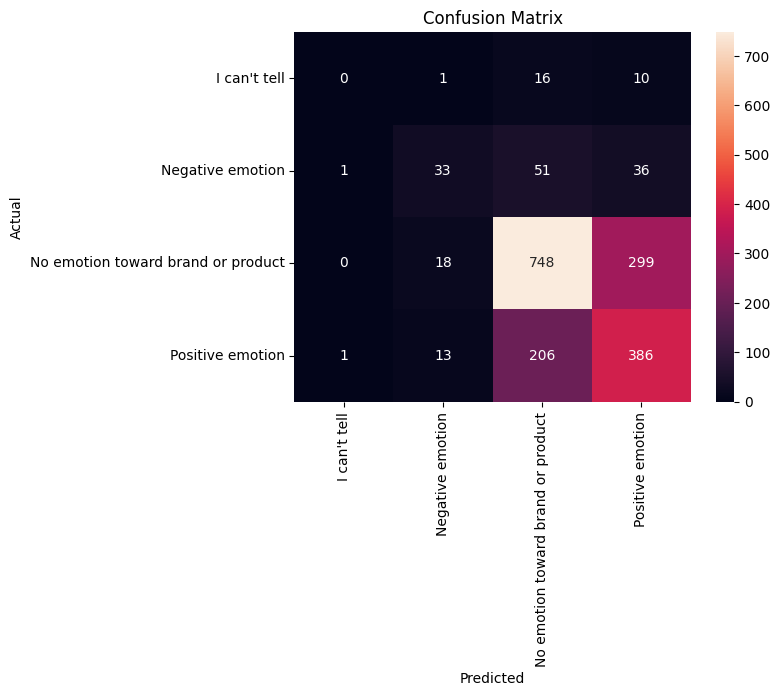

In [87]:
# Get predictions
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

# Generate Classification Report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=label_encoder.classes_))

# Generate Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Step 13: Save Model

In [88]:
# Save the model in .h5 format
model.save('sentiment_analysis_model.h5')
print("Model saved as sentiment_analysis_model.h5")

Model saved as sentiment_analysis_model.h5


# Step 14: Test on Custom Tweets

In [89]:
def predict_new_tweet(text):
    # Clean and tokenize the input
    cleaned = clean_tweet(text)
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=max_len)

    # Predict
    pred = model.predict(padded)
    label_idx = np.argmax(pred)

    # Convert number back to text label
    return label_encoder.inverse_transform([label_idx])[0]

# Test tweets
print(predict_new_tweet("I absolutely love my new Google Pixel phone!"))
print(predict_new_tweet("The battery life on this iPhone is terrible."))
print(predict_new_tweet("I am going to the tech conference tomorrow."))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Positive emotion
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
No emotion toward brand or product
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
No emotion toward brand or product


# **Trying a improved bidirectional LSTM to check for a better accuracy**

# Step 15: Build the Model (Improved Bidirectional LSTM)

In [90]:
# Define the improved architecture
model = Sequential([
    Embedding(max_words, 128, input_length=max_len),
    Bidirectional(LSTM(64, return_sequences=True)), # First Bidirectional layer
    Bidirectional(LSTM(32)),                        # Second Bidirectional layer
    Dense(64, activation='relu'),                   # Extra learning layer
    Dropout(0.3),                                   # Dropout to prevent overfitting
    Dense(4, activation='softmax')                  # Output layer (4 classes)
])

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_8 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_4 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_5 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

# Step 16: Train the Improved Bidirectional LSTM Model

In [91]:
# Training the model
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 56s 222ms/step - accuracy: 0.5939 - loss: 0.9276 - val_accuracy: 0.6484 - val_loss: 0.8105
Epoch 2/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 83s 230ms/step - accuracy: 0.6979 - loss: 0.7640 - val_accuracy: 0.6813 - val_loss: 0.8022
Epoch 3/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 81s 224ms/step - accuracy: 0.7749 - loss: 0.6005 - val_accuracy: 0.6703 - val_loss: 0.7935
Epoch 4/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 45s 222ms/step - accuracy: 0.8237 - loss: 0.4815 - val_accuracy: 0.6538 - val_loss: 0.9522
Epoch 5/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 82s 221ms/step - accuracy: 0.8506 - loss: 0.3912 - val_accuracy: 0.6470 - val_loss: 1.1135
Epoch 6/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 45s 220ms/step - accuracy: 0.8739 - loss: 0.3306 - val_accuracy: 0.6442 - val_loss: 1.1095
Epoch 7/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 84s 229ms/step - accuracy: 0.8856 - loss: 0.2833 - val_accuracy: 0.6346 - val_loss: 1.3266
Epoch 8/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 80s 221ms/step - accuracy: 0.8932 - loss: 0

# Step 17: Evaluate Improved Bidirectional LSTM Model

57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - accuracy: 0.6229 - loss: 1.8761
Improved Test Accuracy: 62.29%


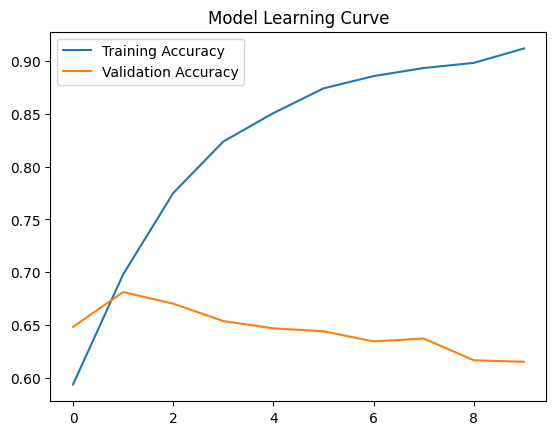

In [92]:
# Evaluate the model's accuracy
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Improved Test Accuracy: {accuracy * 100:.2f}%")

# Plot the training history
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Learning Curve')
plt.legend()
plt.show()

# Step 18: Save Improved Bidirectional LSTM Model

In [93]:
# Save the model
model.save('final_tweet_sentiment_model.h5')
print("Model saved successfully as final_tweet_sentiment_model.h5")

Model saved successfully as final_tweet_sentiment_model.h5


# Step 19: Test on Custom Tweets

In [95]:
def test_my_tweet(text):
    # Clean and prepare the input tweet
    cleaned = clean_tweet(text)
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=max_len)

    # Run prediction
    prediction = model.predict(padded)
    label_idx = np.argmax(prediction)

    # Return the readable sentiment label
    return label_encoder.inverse_transform([label_idx])[0]

# Test tweets
print(f"Result 1: {test_my_tweet('I love using the new iPad, it is so fast!')}")
print(f"Result 2: {test_my_tweet('Google search is really annoying today.')}")
print(f"Result 3: {test_my_tweet('I am attending a conference in Bangalore.')}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
Result 1: Positive emotion
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
Result 2: I can't tell
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
Result 3: No emotion toward brand or product
